In [5]:
!pip install -q kaggle

In [6]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"varshanasankar","key":"0b79abffd6be5c5160e158efb228b2e8"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d tommyngx/cgmh-kneeseg

Dataset URL: https://www.kaggle.com/datasets/tommyngx/cgmh-kneeseg
License(s): CC0-1.0
100% 587M/587M [00:05<00:00, 103MB/s] 



In [9]:
import os

os.listdir("/content")

['.config', 'kaggle.json', 'cgmh-kneeseg.zip', 'sample_data']

In [10]:
!unzip -q cgmh-kneeseg.zip -d /content/kneeseg

In [11]:
import os

for root, dirs, files in os.walk("/content/kneeseg"):
    print(root, len(files))

/content/kneeseg 0
/content/kneeseg/CGMH_KneeSegment 0
/content/kneeseg/CGMH_KneeSegment/Label 400
/content/kneeseg/CGMH_KneeSegment/Image 400


In [12]:
import os

for root, dirs, files in os.walk("/content/kneeseg"):
    print("FOLDER:", root)
    print("SUBFOLDERS:", dirs)
    print("FILES:", len(files))
    print("-" * 50)

FOLDER: /content/kneeseg
SUBFOLDERS: ['CGMH_KneeSegment']
FILES: 0
--------------------------------------------------
FOLDER: /content/kneeseg/CGMH_KneeSegment
SUBFOLDERS: ['Label', 'Image']
FILES: 0
--------------------------------------------------
FOLDER: /content/kneeseg/CGMH_KneeSegment/Label
SUBFOLDERS: []
FILES: 400
--------------------------------------------------
FOLDER: /content/kneeseg/CGMH_KneeSegment/Image
SUBFOLDERS: []
FILES: 400
--------------------------------------------------


In [13]:
import os

print("Contents of /content/kneeseg:")
print(os.listdir("/content/kneeseg"))

Contents of /content/kneeseg:
['CGMH_KneeSegment']


In [14]:
print(os.listdir("/content/kneeseg/CGMH_KneeSegment"))

['Label', 'Image']


In [15]:
import os

base_path = "/content/kneeseg"

for root, dirs, files in os.walk(base_path):
    print("FOLDER:", root)
    print("NUMBER OF FILES:", len(files))
    print("-" * 50)

FOLDER: /content/kneeseg
NUMBER OF FILES: 0
--------------------------------------------------
FOLDER: /content/kneeseg/CGMH_KneeSegment
NUMBER OF FILES: 0
--------------------------------------------------
FOLDER: /content/kneeseg/CGMH_KneeSegment/Label
NUMBER OF FILES: 400
--------------------------------------------------
FOLDER: /content/kneeseg/CGMH_KneeSegment/Image
NUMBER OF FILES: 400
--------------------------------------------------


In [16]:
import os

base_path = "/content/kneeseg"

image_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

for root, dirs, files in os.walk(base_path):
    image_files = [f for f in files if f.lower().endswith(image_extensions)]

    if image_files:
        print("\nFOLDER:", root)
        print("Number of images:", len(image_files))
        print("Example files:", image_files[:5])


FOLDER: /content/kneeseg/CGMH_KneeSegment/Label
Number of images: 400
Example files: ['2695_1.png', '613_1.png', '2383_0.png', '3033_1.png', '535_1.png']

FOLDER: /content/kneeseg/CGMH_KneeSegment/Image
Number of images: 400
Example files: ['2695_1.png', '613_1.png', '2383_0.png', '3033_1.png', '535_1.png']


In [17]:
import os

for root, dirs, files in os.walk("/content/kneeseg"):
    label_files = [
        f for f in files
        if any(x in f.lower() for x in ["label", "mask", "seg"])
    ]

    if label_files:
        print("\nLABEL FOLDER:", root)
        print("Number of label files:", len(label_files))
        print("Example:", label_files[:5])

In [21]:
femur_path = "/content/kneeseg/CGMH_KneeSegment/Label"
tibia_path = "/content/kneeseg/CGMH_KneeSegment/Label"

print("Femur path:")
print(femur_path)

print("\nTibia path:")
print(tibia_path)

Femur path:
/content/kneeseg/CGMH_KneeSegment/Label

Tibia path:
/content/kneeseg/CGMH_KneeSegment/Label


In [22]:
import os

for root, dirs, files in os.walk("/content/kneeseg"):
    if files:
        print("\nFOLDER:", root)
        print("FILES:")
        for f in files[:20]:
            print("  ", f)


FOLDER: /content/kneeseg/CGMH_KneeSegment/Label
FILES:
   2695_1.png
   613_1.png
   2383_0.png
   3033_1.png
   535_1.png
   361_1.png
   986_1.png
   849_1.png
   313_1.png
   26_0.png
   70_1.png
   698_0.png
   527_1.png
   2725_1.png
   820_1.png
   95_0.png
   608_1.png
   561_1.png
   929_1.png
   514_1.png

FOLDER: /content/kneeseg/CGMH_KneeSegment/Image
FILES:
   2695_1.png
   613_1.png
   2383_0.png
   3033_1.png
   535_1.png
   361_1.png
   986_1.png
   849_1.png
   313_1.png
   26_0.png
   70_1.png
   698_0.png
   527_1.png
   2725_1.png
   820_1.png
   95_0.png
   608_1.png
   561_1.png
   929_1.png
   514_1.png


In [24]:
import numpy as np
from PIL import Image
from scipy import ndimage

label_path = "/content/kneeseg/CGMH_KneeSegment/Label/642_1.png"

label = np.array(Image.open(label_path))

# Convert to binary
binary = label > 0

# Find connected components
components, num_components = ndimage.label(binary)

print("Number of connected components:", num_components)

for i in range(1, num_components + 1):
    ys, xs = np.where(components == i)

    print(
        f"Component {i}: "
        f"pixels={len(xs)}, "
        f"x-range=({xs.min()}, {xs.max()}), "
        f"y-range=({ys.min()}, {ys.max()})"
    )

Number of connected components: 2
Component 1: pixels=183073, x-range=(326, 874), y-range=(822, 1258)
Component 2: pixels=131201, x-range=(279, 798), y-range=(1209, 1576)


In [25]:
import numpy as np
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt

label_path = "/content/kneeseg/CGMH_KneeSegment/Label/642_1.png"

label = np.array(Image.open(label_path))

# Binary mask
binary = label > 0

# Find connected components
components, num_components = ndimage.label(binary)

# Get components sorted by their vertical position
component_info = []

for i in range(1, num_components + 1):
    ys, xs = np.where(components == i)

    component_info.append({
        "id": i,
        "min_y": ys.min(),
        "max_y": ys.max(),
        "pixels": len(xs)
    })

component_info.sort(key=lambda x: x["min_y"])

# Upper component = femur
femur_mask = (components == component_info[0]["id"]).astype(np.uint8) * 255

# Lower component = tibia
tibia_mask = (components == component_info[1]["id"]).astype(np.uint8) * 255

print("Femur pixels:", np.sum(femur_mask > 0))
print("Tibia pixels:", np.sum(tibia_mask > 0))

Femur pixels: 183073
Tibia pixels: 131201


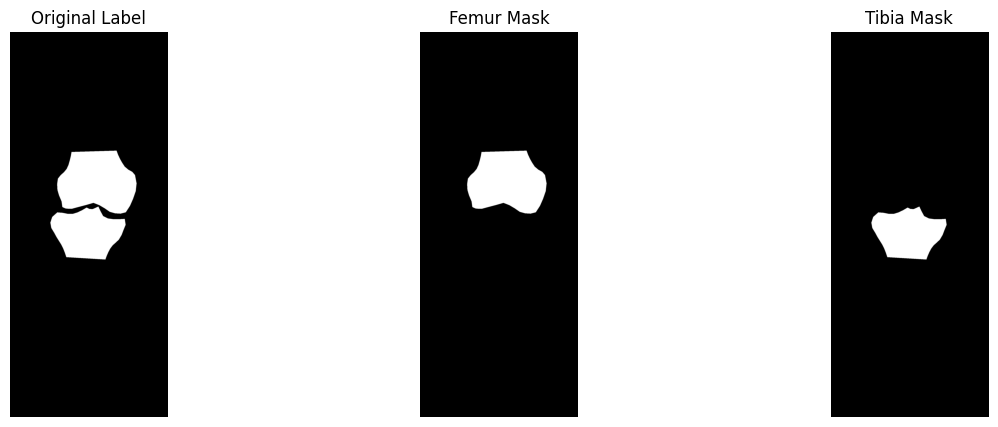

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(label, cmap="gray")
axes[0].set_title("Original Label")
axes[0].axis("off")

axes[1].imshow(femur_mask, cmap="gray")
axes[1].set_title("Femur Mask")
axes[1].axis("off")

axes[2].imshow(tibia_mask, cmap="gray")
axes[2].set_title("Tibia Mask")
axes[2].axis("off")

plt.show()

In [27]:
import os
import numpy as np
from PIL import Image
from scipy import ndimage

image_dir = "/content/kneeseg/CGMH_KneeSegment/Image"
label_dir = "/content/kneeseg/CGMH_KneeSegment/Label"

label_files = [
    f for f in os.listdir(label_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

total = len(label_files)
two_components = 0
other_components = 0

for filename in label_files:
    label_path = os.path.join(label_dir, filename)

    label = np.array(Image.open(label_path))
    binary = label > 0

    _, num_components = ndimage.label(binary)

    if num_components == 2:
        two_components += 1
    else:
        other_components += 1

print("Total labels:", total)
print("Labels with exactly 2 components:", two_components)
print("Labels with other number of components:", other_components)

Total labels: 400
Labels with exactly 2 components: 394
Labels with other number of components: 6


In [29]:
import os
import numpy as np
from PIL import Image
from scipy import ndimage

image_dir = "/content/kneeseg/CGMH_KneeSegment/Image"
label_dir = "/content/kneeseg/CGMH_KneeSegment/Label"

output_mask_dir = "/content/kneeseg/CGMH_KneeSegment/UNet_Masks"

os.makedirs(output_mask_dir, exist_ok=True)

label_files = [
    f for f in os.listdir(label_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

successful = 0
skipped = 0

for filename in label_files:

    label_path = os.path.join(label_dir, filename)

    label = np.array(Image.open(label_path))

    # Binary mask
    binary = label > 0

    # Connected components
    components, num_components = ndimage.label(binary)

    # If fewer than 2 components, skip this image
    if num_components < 2:
        print("Skipping:", filename,
              "| Components found:", num_components)
        skipped += 1
        continue

    # Get component information
    component_info = []

    for i in range(1, num_components + 1):

        ys, xs = np.where(components == i)

        component_info.append({
            "id": i,
            "min_y": ys.min(),
            "pixels": len(xs)
        })

    # Sort components from top to bottom
    component_info.sort(key=lambda x: x["min_y"])

    # Create multiclass mask
    multiclass_mask = np.zeros(label.shape, dtype=np.uint8)

    # Upper component → Femur = 1
    multiclass_mask[
        components == component_info[0]["id"]
    ] = 1

    # Lower component → Tibia = 2
    multiclass_mask[
        components == component_info[1]["id"]
    ] = 2

    # Save
    output_path = os.path.join(output_mask_dir, filename)

    Image.fromarray(multiclass_mask).save(output_path)

    successful += 1

print("\n========== SUMMARY ==========")
print("Total labels:", len(label_files))
print("Successfully processed:", successful)
print("Skipped:", skipped)
print("Output folder:", output_mask_dir)

Skipping: 313_1.png | Components found: 1
Skipping: 2354_0.png | Components found: 1
Skipping: 524_1.png | Components found: 1
Skipping: 2828_1.png | Components found: 1
Skipping: 652_1.png | Components found: 1

========== SUMMARY ==========
Total labels: 400
Successfully processed: 395
Skipped: 5
Output folder: /content/kneeseg/CGMH_KneeSegment/UNet_Masks


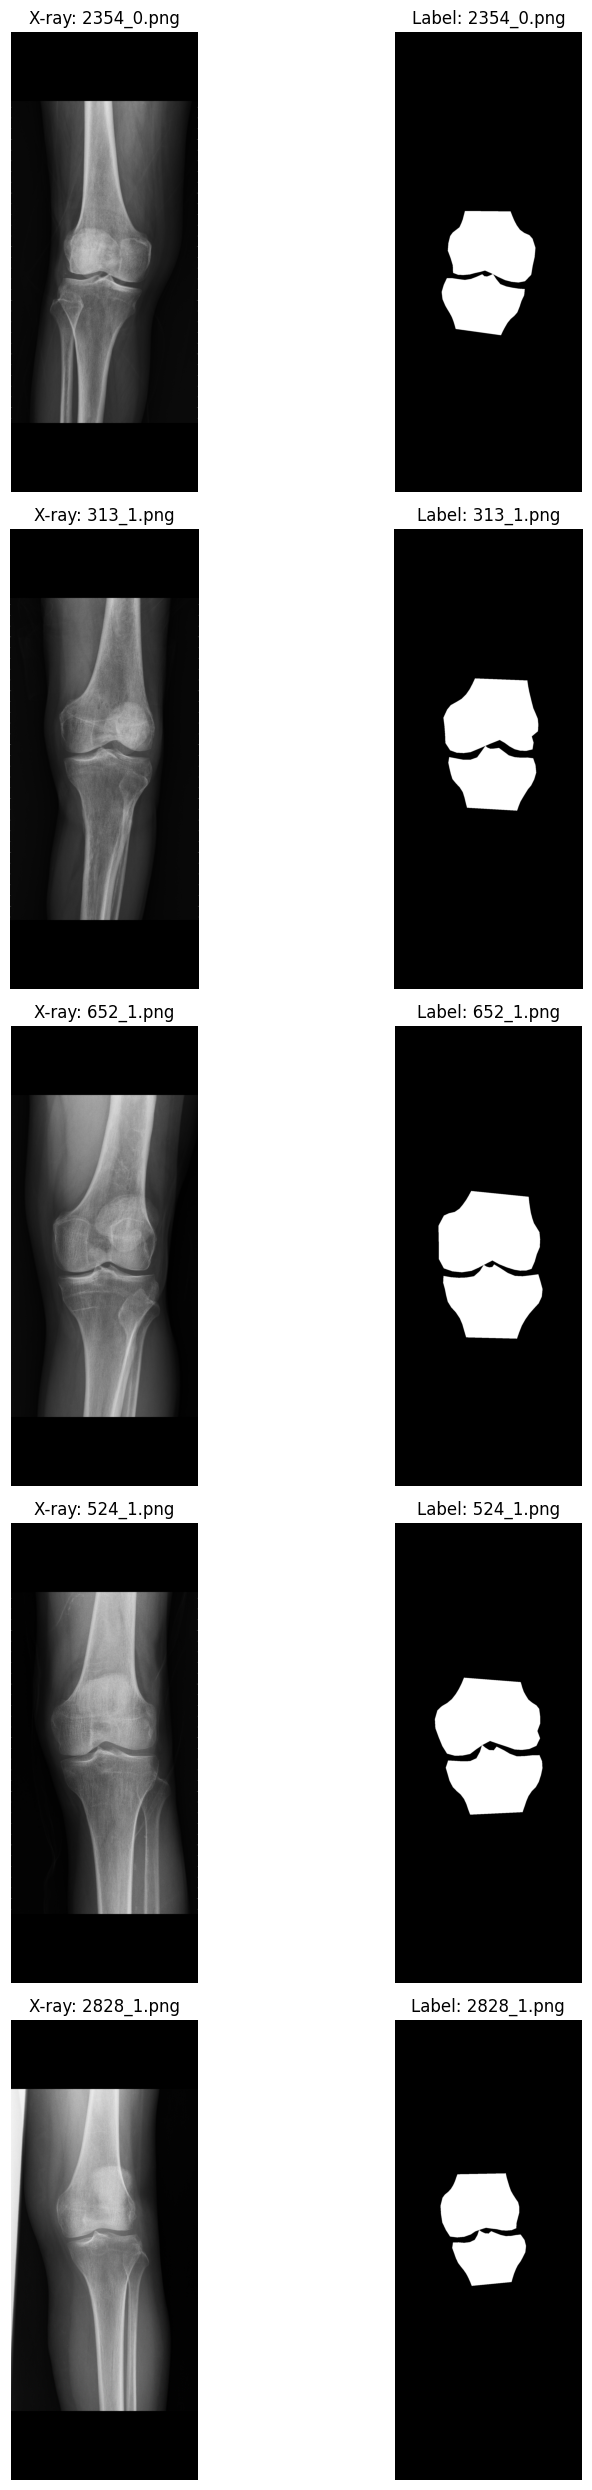

In [30]:
import matplotlib.pyplot as plt
import os
import numpy as np
from PIL import Image

image_dir = "/content/kneeseg/CGMH_KneeSegment/Image"
label_dir = "/content/kneeseg/CGMH_KneeSegment/Label"

skipped_files = [
    "2354_0.png",
    "313_1.png",
    "652_1.png",
    "524_1.png",
    "2828_1.png"
]

fig, axes = plt.subplots(5, 2, figsize=(10, 25))

for i, filename in enumerate(skipped_files):

    image = np.array(
        Image.open(os.path.join(image_dir, filename))
    )

    label = np.array(
        Image.open(os.path.join(label_dir, filename))
    )

    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title(f"X-ray: {filename}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(label, cmap="gray")
    axes[i, 1].set_title(f"Label: {filename}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [31]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

image_dir = "/content/kneeseg/CGMH_KneeSegment/Image"
label_dir = "/content/kneeseg/CGMH_KneeSegment/Label"
output_mask_dir = "/content/kneeseg/CGMH_KneeSegment/UNet_Masks"

special_files = [
    "2354_0.png",
    "313_1.png",
    "652_1.png",
    "524_1.png",
    "2828_1.png"
]

for filename in special_files:

    label_path = os.path.join(label_dir, filename)

    label = np.array(Image.open(label_path))

    binary = label > 0

    # Count white pixels in every row
    row_counts = np.sum(binary, axis=1)

    # Find rows containing the segmentation
    nonzero_rows = np.where(row_counts > 0)[0]

    first_row = nonzero_rows[0]
    last_row = nonzero_rows[-1]

    # Search for the minimum amount of mask pixels
    # around the middle of the knee
    middle_start = first_row + int(0.35 * (last_row - first_row))
    middle_end = first_row + int(0.70 * (last_row - first_row))

    search_rows = np.arange(middle_start, middle_end)

    split_row = search_rows[
        np.argmin(row_counts[search_rows])
    ]

    # Create multiclass mask
    multiclass_mask = np.zeros(binary.shape, dtype=np.uint8)

    # Upper part = Femur
    multiclass_mask[:split_row, :][binary[:split_row, :]] = 1

    # Lower part = Tibia
    multiclass_mask[split_row:, :][binary[split_row:, :]] = 2

    # Save
    output_path = os.path.join(output_mask_dir, filename)

    Image.fromarray(multiclass_mask).save(output_path)

    print(filename, "→ split row:", split_row)

print("\n5 special masks processed successfully.")

2354_0.png → split row: 1416
313_1.png → split row: 1300
652_1.png → split row: 1435
524_1.png → split row: 1351
2828_1.png → split row: 1229

5 special masks processed successfully.


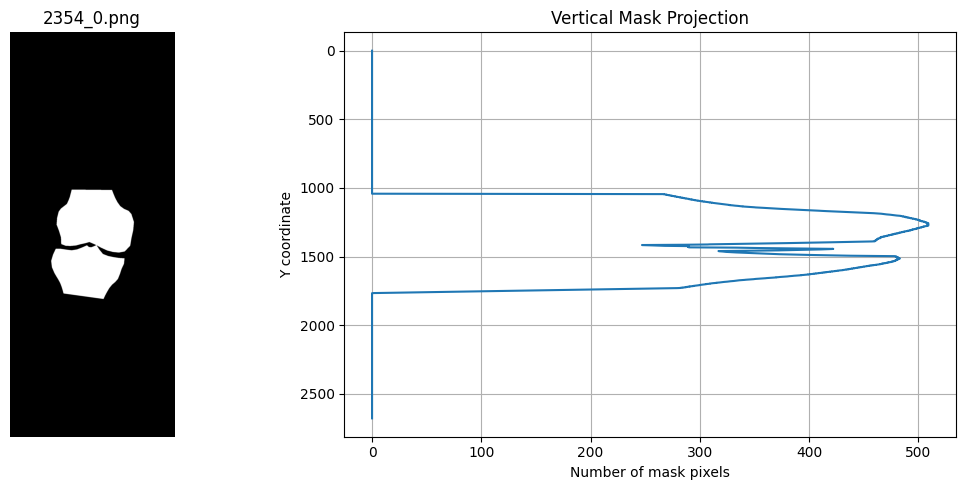

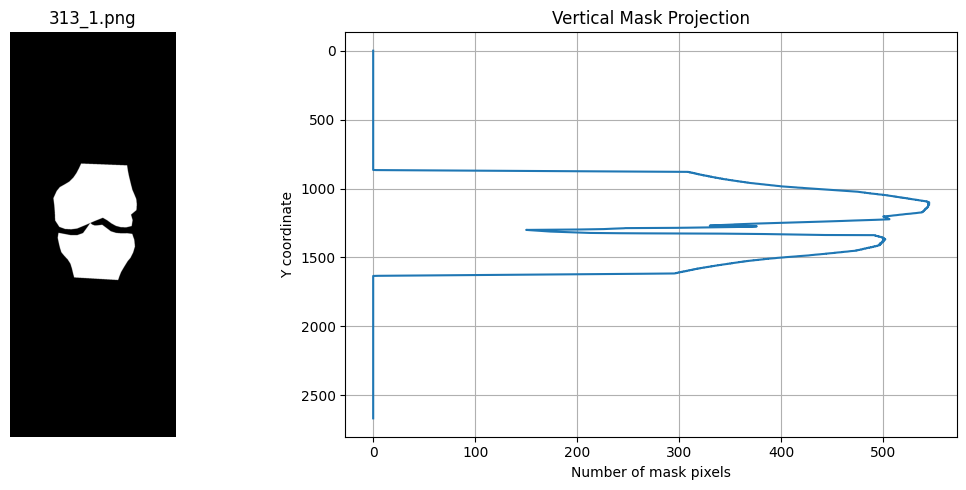

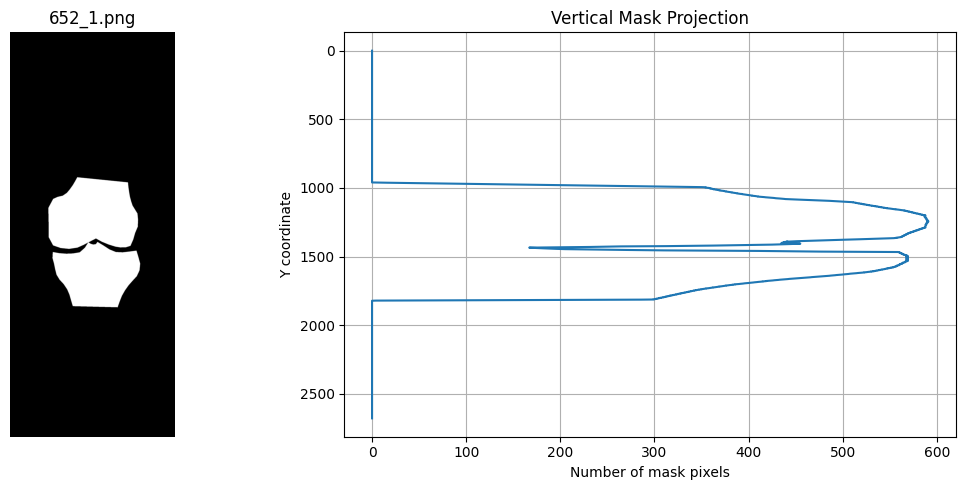

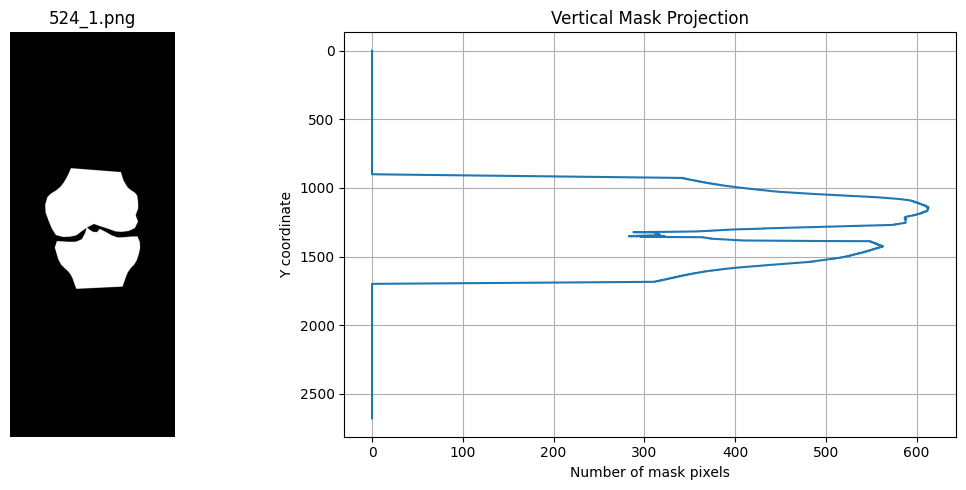

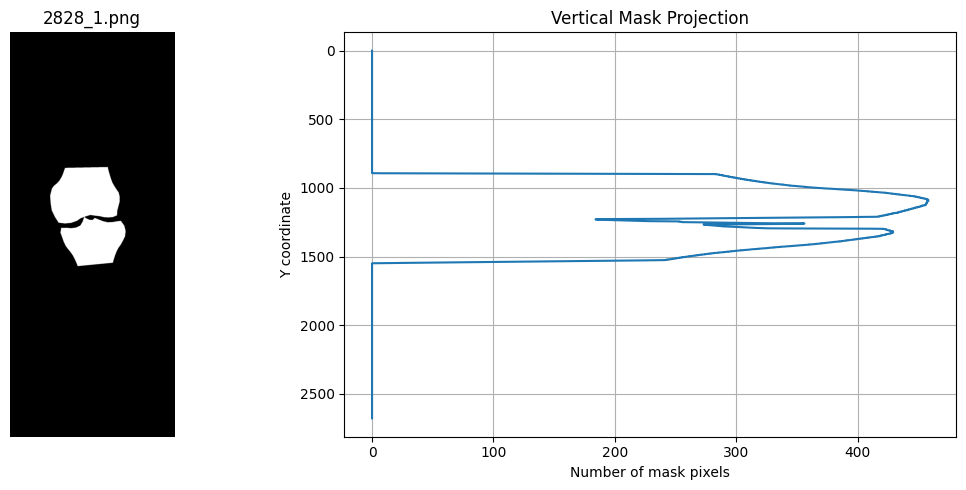

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

label_dir = "/content/kneeseg/CGMH_KneeSegment/Label"

special_files = [
    "2354_0.png",
    "313_1.png",
    "652_1.png",
    "524_1.png",
    "2828_1.png"
]

for filename in special_files:

    label = np.array(
        Image.open(os.path.join(label_dir, filename))
    )

    binary = label > 0

    # Number of foreground pixels in each row
    row_counts = np.sum(binary, axis=1)

    rows = np.arange(len(row_counts))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Original label
    axes[0].imshow(binary, cmap="gray")
    axes[0].set_title(filename)
    axes[0].axis("off")

    # Row projection
    axes[1].plot(row_counts, rows)
    axes[1].invert_yaxis()
    axes[1].set_title("Vertical Mask Projection")
    axes[1].set_xlabel("Number of mask pixels")
    axes[1].set_ylabel("Y coordinate")
    axes[1].grid()

    plt.tight_layout()
    plt.show()

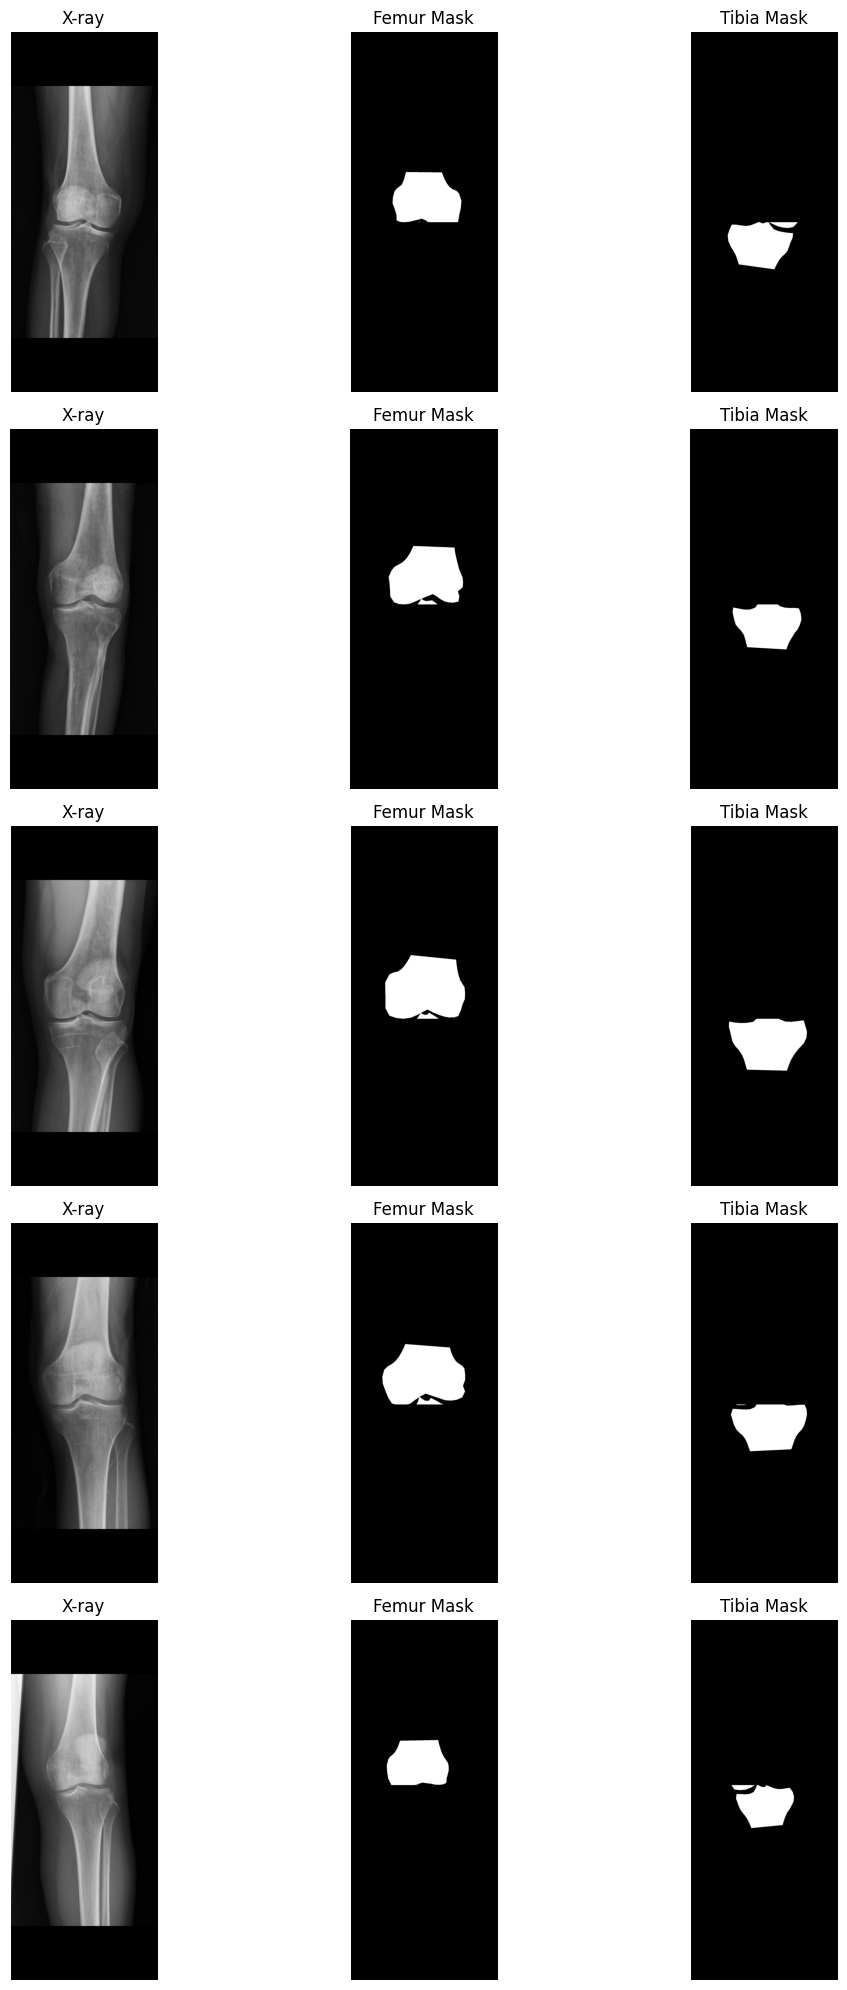

In [33]:
fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for i, filename in enumerate(special_files):

    image = np.array(
        Image.open(os.path.join(
            "/content/kneeseg/CGMH_KneeSegment/Image",
            filename
        ))
    )

    mask = np.array(
        Image.open(os.path.join(
            output_mask_dir,
            filename
        ))
    )

    axes[i, 0].imshow(image, cmap="gray")
    axes[i, 0].set_title("X-ray")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask == 1, cmap="gray")
    axes[i, 1].set_title("Femur Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mask == 2, cmap="gray")
    axes[i, 2].set_title("Tibia Mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [34]:
import os
import numpy as np
from PIL import Image

image_dir = "/content/kneeseg/CGMH_KneeSegment/Image"
mask_dir = "/content/kneeseg/CGMH_KneeSegment/UNet_Masks"

IMG_SIZE = 256

images = []
masks = []
filenames = []

image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

for filename in image_files:

    image_path = os.path.join(image_dir, filename)
    mask_path = os.path.join(mask_dir, filename)

    # Make sure corresponding mask exists
    if not os.path.exists(mask_path):
        print("Missing mask:", filename)
        continue

    # Load X-ray
    image = Image.open(image_path).convert("L")

    # Resize image
    image = image.resize(
        (IMG_SIZE, IMG_SIZE),
        Image.Resampling.BILINEAR
    )

    image = np.array(image, dtype=np.float32)

    # Normalize image to 0-1
    image = image / 255.0

    # Add channel dimension
    image = np.expand_dims(image, axis=-1)

    # Load segmentation mask
    mask = Image.open(mask_path)

    # IMPORTANT:
    # Use NEAREST for masks so class values 0,1,2 are preserved
    mask = mask.resize(
        (IMG_SIZE, IMG_SIZE),
        Image.Resampling.NEAREST
    )

    mask = np.array(mask, dtype=np.uint8)

    images.append(image)
    masks.append(mask)
    filenames.append(filename)

# Convert to NumPy arrays
X = np.array(images, dtype=np.float32)
Y = np.array(masks, dtype=np.uint8)

print("Images shape:", X.shape)
print("Masks shape:", Y.shape)
print("Number of images:", len(X))
print("Number of masks:", len(Y))
print("Mask values:", np.unique(Y))

Images shape: (400, 256, 256, 1)
Masks shape: (400, 256, 256)
Number of images: 400
Number of masks: 400
Mask values: [0 1 2]


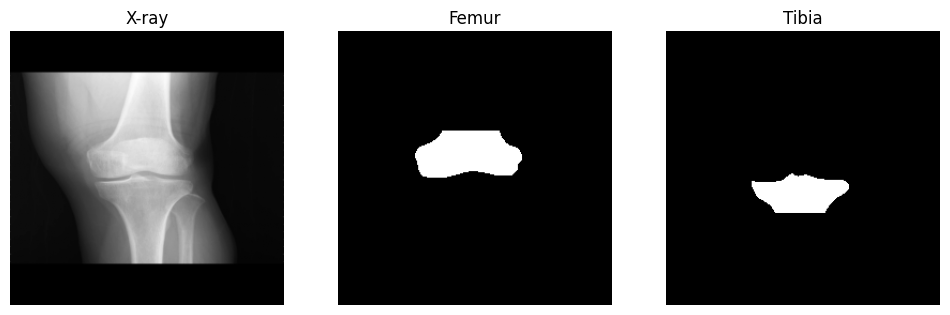

Filename: 1013_0.png


In [35]:
import matplotlib.pyplot as plt

index = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(X[index].squeeze(), cmap="gray")
plt.title("X-ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Y[index] == 1, cmap="gray")
plt.title("Femur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Y[index] == 2, cmap="gray")
plt.title("Tibia")
plt.axis("off")

plt.show()

print("Filename:", filenames[index])

In [36]:
from sklearn.model_selection import train_test_split

# First: 70% train, 30% temporary
X_train, X_temp, Y_train, Y_temp, F_train, F_temp = train_test_split(
    X,
    Y,
    filenames,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Split temporary 50/50 → 15% validation, 15% test
X_val, X_test, Y_val, Y_test, F_val, F_test = train_test_split(
    X_temp,
    Y_temp,
    F_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Training:")
print("X:", X_train.shape)
print("Y:", Y_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("Y:", Y_val.shape)

print("\nTesting:")
print("X:", X_test.shape)
print("Y:", Y_test.shape)

Training:
X: (280, 256, 256, 1)
Y: (280, 256, 256)

Validation:
X: (60, 256, 256, 1)
Y: (60, 256, 256)

Testing:
X: (60, 256, 256, 1)
Y: (60, 256, 256)


In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = 3


def conv_block(inputs, filters):
    x = layers.Conv2D(
        filters,
        3,
        activation="relu",
        padding="same"
    )(inputs)

    x = layers.Conv2D(
        filters,
        3,
        activation="relu",
        padding="same"
    )(x)

    return x


def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)

    p = layers.MaxPooling2D((2, 2))(x)

    return x, p


def decoder_block(inputs, skip_features, filters):
    x = layers.Conv2DTranspose(
        filters,
        2,
        strides=2,
        padding="same"
    )(inputs)

    x = layers.Concatenate()([x, skip_features])

    x = conv_block(x, filters)

    return x


def build_unet(input_shape=(256, 256, 1), num_classes=3):

    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)

    # Bridge
    b1 = conv_block(p4, 512)

    # Decoder
    d1 = decoder_block(b1, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)

    # Output
    outputs = layers.Conv2D(
        num_classes,
        1,
        activation="softmax"
    )(d4)

    model = models.Model(
        inputs,
        outputs,
        name="UNet_Knee_Segmentation"
    )

    return model


model = build_unet()

model.summary()

Model: "UNet_Knee_Segmentation"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,759,587 (29.60 MB)

 Trainable params: 7,759,587 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [39]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

callbacks = [

    ModelCheckpoint(
        "/content/best_unet.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [40]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=50,
    batch_size=4,
    callbacks=callbacks
)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8696 - loss: 0.9546
Epoch 1: val_loss improved from None to 0.23095, saving model to /content/best_unet.keras

Epoch 1: finished saving model to /content/best_unet.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 162ms/step - accuracy: 0.8903 - loss: 0.7086 - val_accuracy: 0.8908 - val_loss: 0.2309 - learning_rate: 1.0000e-04
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8953 - loss: 0.2276
Epoch 2: val_loss did not improve from 0.23095
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.8962 - loss: 0.2245 - val_accuracy: 0.8908 - val_loss: 0.2853 - learning_rate: 1.0000e-04
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9084 - loss: 0.2217
Epoch 3: val_loss improved from 0.23095 to 0.19183, saving model to /content/best_unet.keras

Epoch 3: finished saving model to /content/best_unet.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.9129 - loss: 0.2102 - val_accuracy: 0.9162 - val_lo

In [41]:
import os

print(os.listdir("/content"))

['.config', 'kneeseg', 'kaggle.json', 'best_unet.keras', 'cgmh-kneeseg.zip', 'sample_data']


In [42]:
from tensorflow.keras.models import load_model

model = load_model("/content/best_unet.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [58]:
from google.colab import files

uploaded = files.upload()

Saving Adobe Express - file.png to Adobe Express - file.png


(1088, 2680)


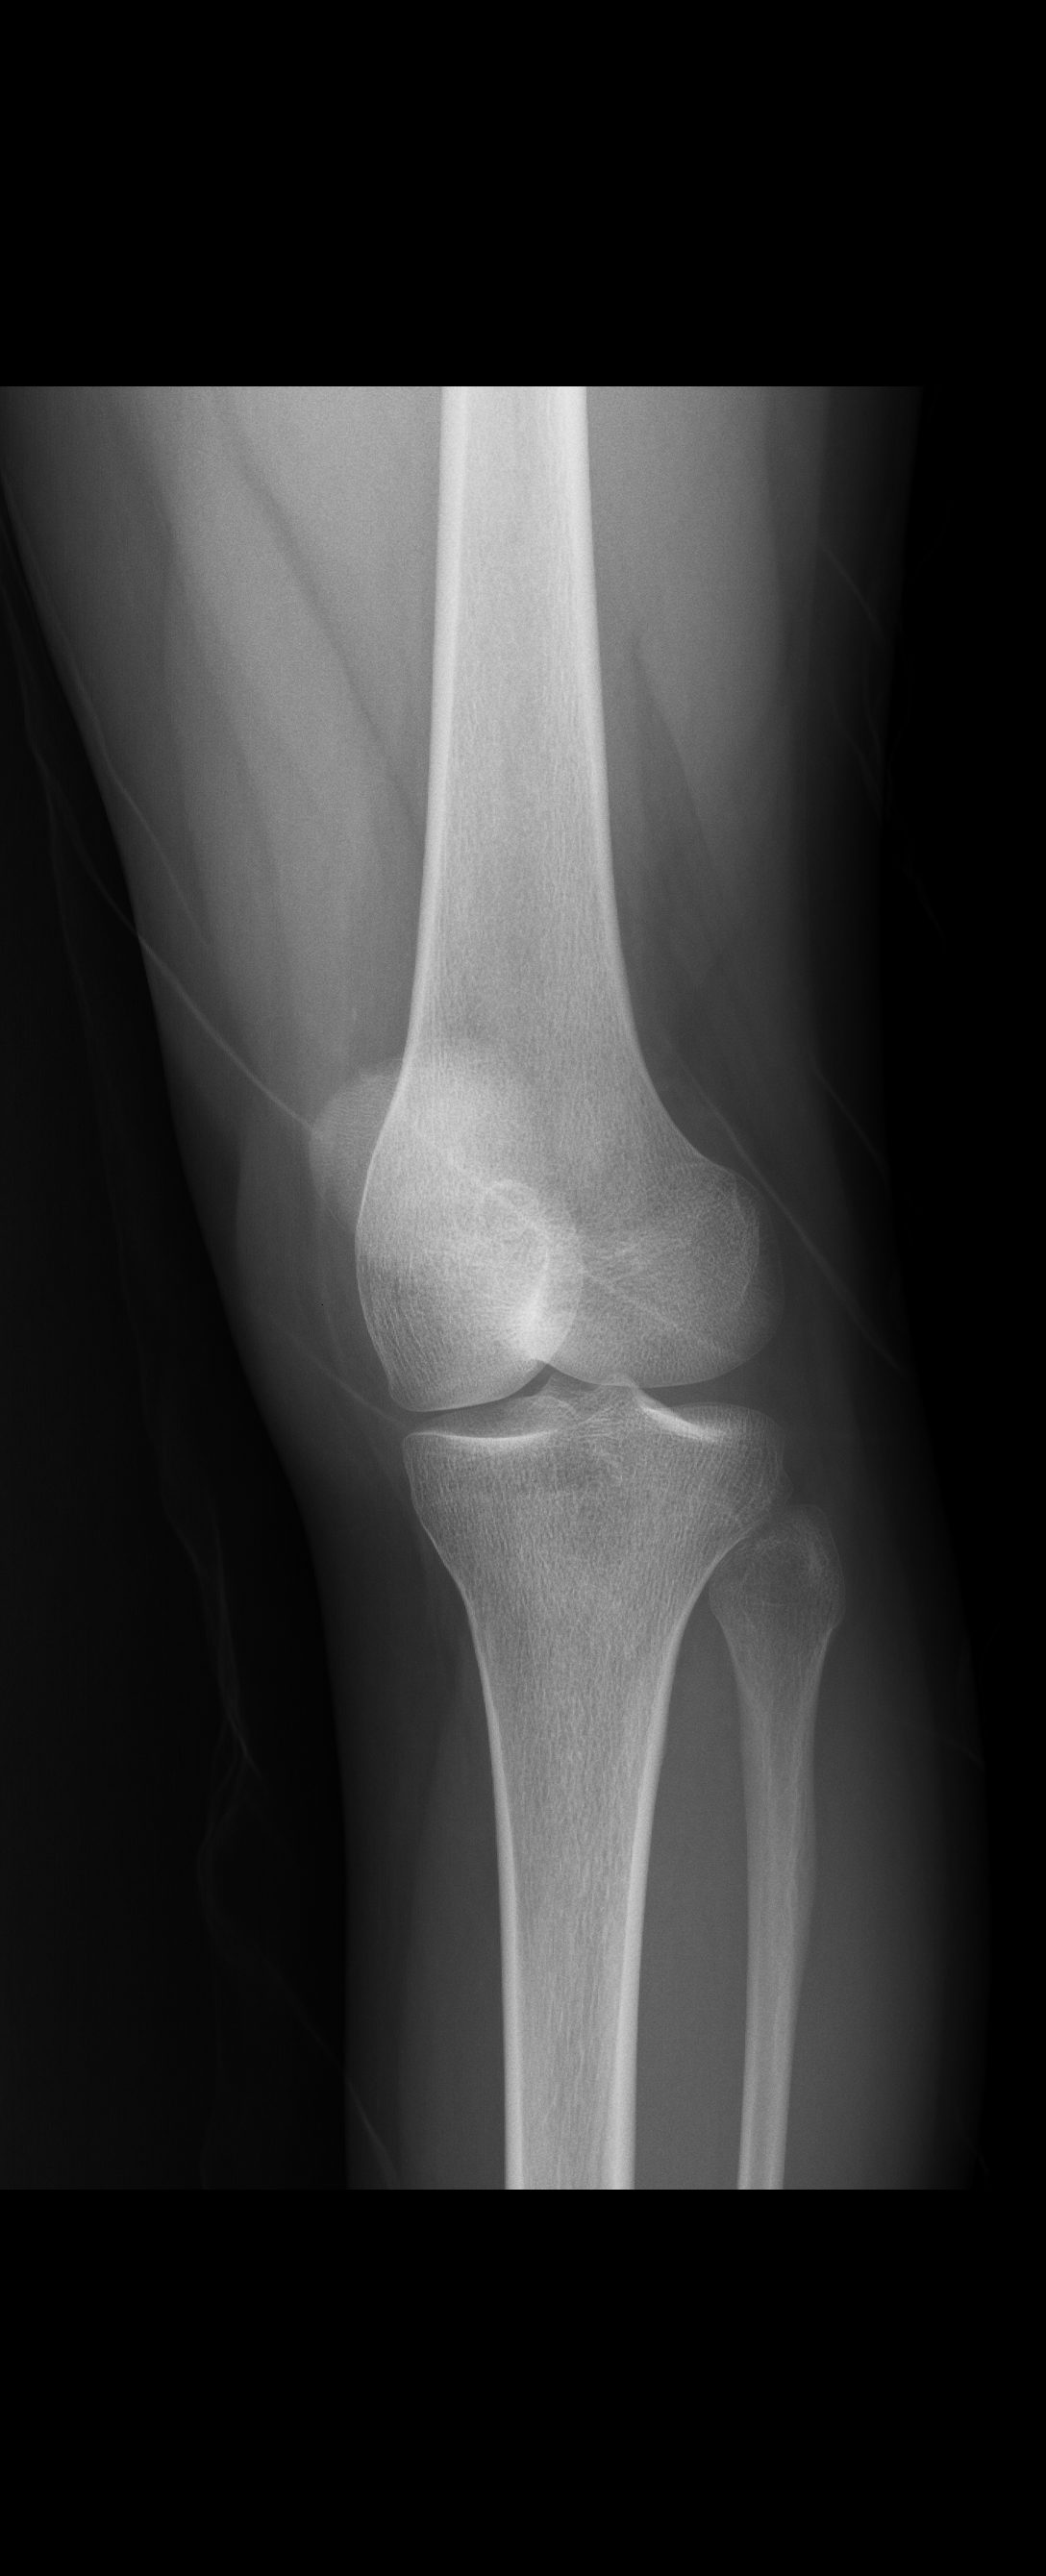

In [59]:
from PIL import Image

img = Image.open(test_image_path)
print(img.size)
display(img)

In [60]:
import numpy as np

print("Image mode:", img.mode)
print("Image size:", img.size)

Image mode: RGB
Image size: (1088, 2680)


In [61]:
img_array = np.array(img)

print("Array shape:", img_array.shape)
print("Data type:", img_array.dtype)

Array shape: (2680, 1088, 3)
Data type: uint8


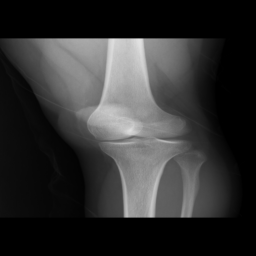

In [77]:
from PIL import Image

# Ensure img is converted to grayscale *before* resizing if it's not already.
# Or, ensure that img.resize is consistent with training.
# Training used BILINEAR resampling.
img_resized = img.resize((256, 256), Image.Resampling.BILINEAR)

display(img_resized)

In [71]:
img_array = np.array(img_resized.convert("L")).astype(np.float32) / 255.0

print("Shape:", img_array.shape)
print("Min:", img_array.min())
print("Max:", img_array.max())

Shape: (256, 256)
Min: 0.0
Max: 0.9254902


In [74]:
input_image = np.expand_dims(img_array, axis=0)
input_image = np.expand_dims(input_image, axis=-1)

print("Input shape:", input_image.shape)

Input shape: (1, 256, 256, 1)


In [75]:
prediction = model.predict(input_image)

print("Prediction shape:", prediction.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction shape: (1, 256, 256, 3)


In [78]:
print("Input shape:", input_image.shape)
print("Prediction shape:", prediction.shape)

Input shape: (1, 256, 256, 1)
Prediction shape: (1, 256, 256, 3)


Predicted mask shape: (256, 256)
Predicted mask values: [0 1 2]


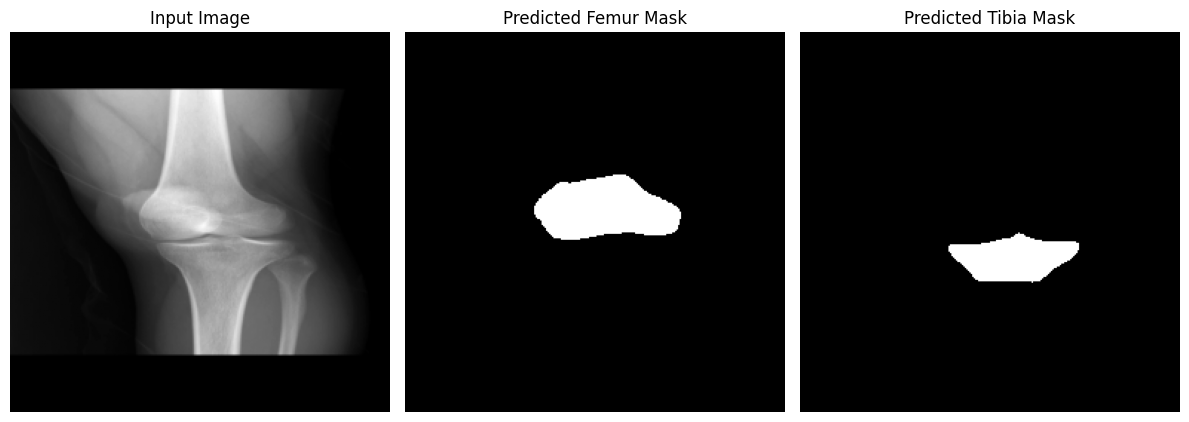

In [80]:
import matplotlib.pyplot as plt

# Get the predicted class for each pixel by taking the argmax along the last axis
predicted_mask = np.argmax(prediction, axis=-1)

# The output mask will have shape (1, 256, 256). Squeeze to remove the batch dimension.
predicted_mask = predicted_mask.squeeze()

print("Predicted mask shape:", predicted_mask.shape)
print("Predicted mask values:", np.unique(predicted_mask))

# Visualize the predicted masks
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_resized.convert("L"), cmap="gray")  # Display the grayscale input image
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(predicted_mask == 1, cmap="gray") # Femur (class 1)
plt.title("Predicted Femur Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(predicted_mask == 2, cmap="gray") # Tibia (class 2)
plt.title("Predicted Tibia Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [87]:
import numpy as np

print("Prediction shape:", prediction.shape)

mask = np.argmax(prediction[0], axis=-1)

print("Mask shape:", mask.shape)
print("Unique classes:", np.unique(mask))

Prediction shape: (1, 256, 256, 3)
Mask shape: (256, 256)
Unique classes: [0 1 2]


In [88]:
for cls in np.unique(mask):
    print(f"Class {cls}: {np.sum(mask == cls)} pixels")

Class 0: 60445 pixels
Class 1: 3160 pixels
Class 2: 1931 pixels


In [92]:
femur_mask = (mask == 1)
tibia_mask = (mask == 2)

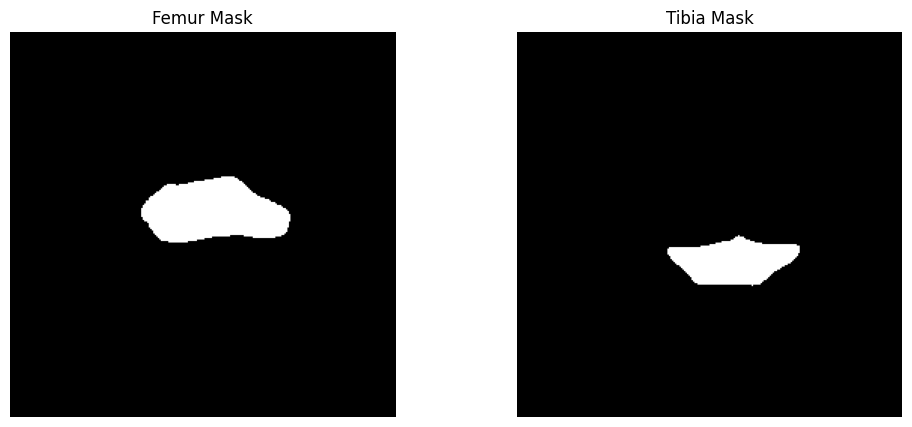

In [93]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(femur_mask, cmap="gray")
plt.title("Femur Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tibia_mask, cmap="gray")
plt.title("Tibia Mask")
plt.axis("off")

plt.show()

In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert boolean masks to uint8
femur = (femur_mask.astype(np.uint8) * 255)
tibia = (tibia_mask.astype(np.uint8) * 255)

# Remove small noisy regions
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    femur, connectivity=8
)

if num_labels > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    femur_clean = np.where(labels == largest, 255, 0).astype(np.uint8)
else:
    femur_clean = femur

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    tibia, connectivity=8
)

if num_labels > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    tibia_clean = np.where(labels == largest, 255, 0).astype(np.uint8)
else:
    tibia_clean = tibia

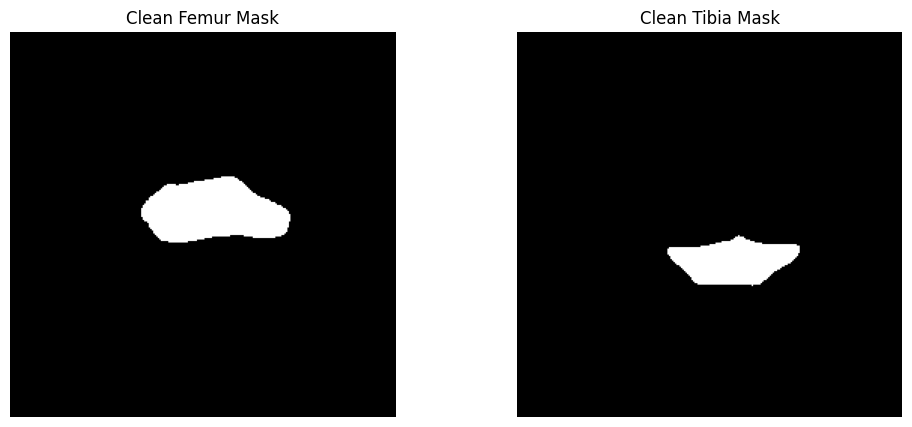

In [95]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(femur_clean, cmap="gray")
plt.title("Clean Femur Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tibia_clean, cmap="gray")
plt.title("Clean Tibia Mask")
plt.axis("off")

plt.show()

In [96]:
def get_bbox(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    return {
        "x_min": xs.min(),
        "x_max": xs.max(),
        "y_min": ys.min(),
        "y_max": ys.max()
    }

femur_bbox = get_bbox(femur_clean)
tibia_bbox = get_bbox(tibia_clean)

print("Femur:", femur_bbox)
print("Tibia:", tibia_bbox)

Femur: {'x_min': np.int64(87), 'x_max': np.int64(185), 'y_min': np.int64(96), 'y_max': np.int64(139)}
Tibia: {'x_min': np.int64(100), 'x_max': np.int64(187), 'y_min': np.int64(135), 'y_max': np.int64(168)}


In [98]:
def crop_region(mask, fraction=0.25, region="bottom"):
    ys, xs = np.where(mask > 0)

    if len(ys) == 0:
        return np.zeros_like(mask)

    y_min, y_max = ys.min(), ys.max()
    height = y_max - y_min

    if region == "bottom":
        cutoff = int(y_max - height * fraction)
        region_mask = mask.copy()
        region_mask[:cutoff, :] = 0

    elif region == "top":
        cutoff = int(y_min + height * fraction)
        region_mask = mask.copy()
        region_mask[cutoff:, :] = 0

    return region_mask


distal_femur = crop_region(
    femur_clean,
    fraction=0.30,
    region="bottom"
)

proximal_tibia = crop_region(
    tibia_clean,
    fraction=0.30,
    region="top"
)

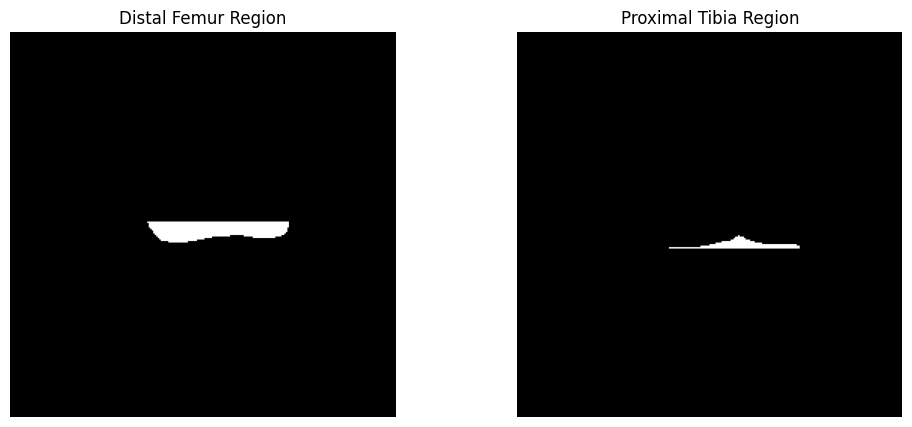

In [99]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(distal_femur, cmap="gray")
plt.title("Distal Femur Region")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(proximal_tibia, cmap="gray")
plt.title("Proximal Tibia Region")
plt.axis("off")

plt.show()

In [100]:
def maximum_width(mask):
    widths = []

    for y in range(mask.shape[0]):
        xs = np.where(mask[y] > 0)[0]

        if len(xs) > 0:
            widths.append(xs.max() - xs.min() + 1)

    return max(widths) if widths else 0


distal_femur_width_px = maximum_width(distal_femur)
proximal_tibia_width_px = maximum_width(proximal_tibia)

print("Distal femur width:", distal_femur_width_px, "px")
print("Proximal tibia width:", proximal_tibia_width_px, "px")

Distal femur width: 94 px
Proximal tibia width: 87 px


In [101]:
import matplotlib.pyplot as plt
import numpy as np

def get_max_width_line(mask):
    best_width = 0
    best_y = None
    best_x1 = None
    best_x2 = None

    for y in range(mask.shape[0]):
        xs = np.where(mask[y] > 0)[0]

        if len(xs) > 1:
            width = xs[-1] - xs[0] + 1

            if width > best_width:
                best_width = width
                best_y = y
                best_x1 = xs[0]
                best_x2 = xs[-1]

    return best_width, best_y, best_x1, best_x2


f_width, f_y, f_x1, f_x2 = get_max_width_line(distal_femur)
t_width, t_y, t_x1, t_x2 = get_max_width_line(proximal_tibia)

print("Distal femur:", f_width, "px")
print("Proximal tibia:", t_width, "px")

Distal femur: 94 px
Proximal tibia: 87 px


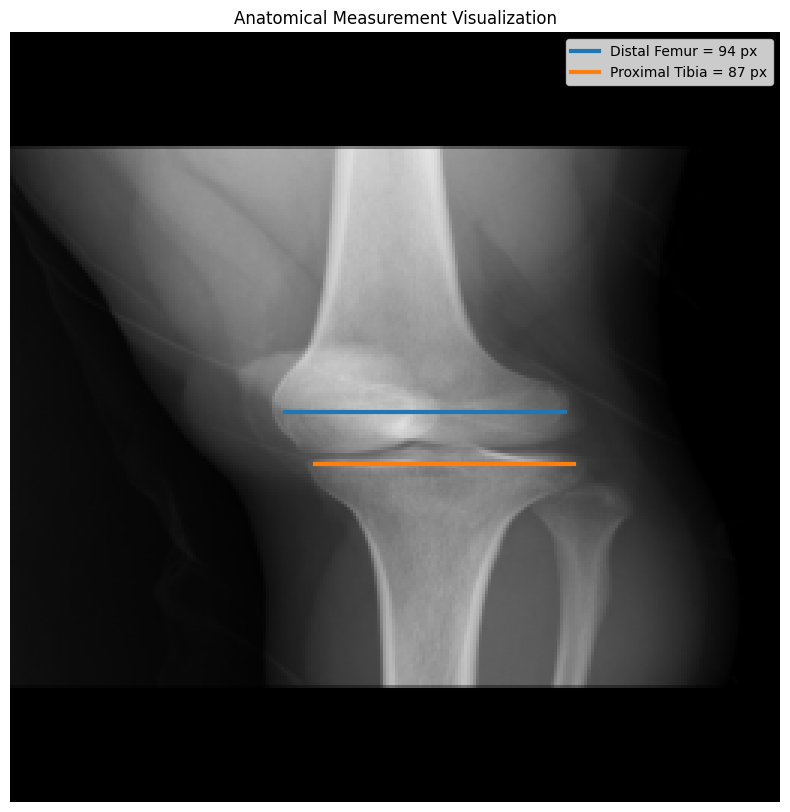

In [102]:
plt.figure(figsize=(10, 10))

plt.imshow(img_resized, cmap="gray")

# Femur measurement
if f_y is not None:
    plt.plot(
        [f_x1, f_x2],
        [f_y, f_y],
        linewidth=3,
        label=f"Distal Femur = {f_width} px"
    )

# Tibia measurement
if t_y is not None:
    plt.plot(
        [np.where(proximal_tibia[t_y] > 0)[0][0],
         np.where(proximal_tibia[t_y] > 0)[0][-1]],
        [t_y, t_y],
        linewidth=3,
        label=f"Proximal Tibia = {t_width} px"
    )

plt.title("Anatomical Measurement Visualization")
plt.legend()
plt.axis("off")
plt.show()

In [103]:
import numpy as np
import matplotlib.pyplot as plt

# Get y-coordinates of femur and tibia masks
femur_y = np.where(femur_clean > 0)[0]
tibia_y = np.where(tibia_clean > 0)[0]

femur_bottom = femur_y.max()
tibia_top = tibia_y.min()

print("Femur bottom:", femur_bottom)
print("Tibia top:", tibia_top)

# Approximate joint-line region
joint_y = (femur_bottom + tibia_top) // 2

print("Approximate joint line:", joint_y)

Femur bottom: 139
Tibia top: 135
Approximate joint line: 137


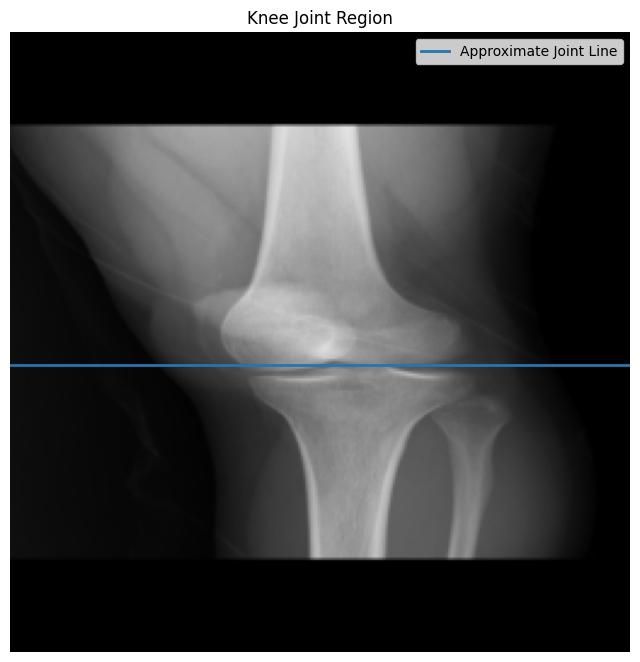

In [104]:
plt.figure(figsize=(8, 10))

plt.imshow(img_resized, cmap="gray")

plt.axhline(
    joint_y,
    linewidth=2,
    label="Approximate Joint Line"
)

plt.title("Knee Joint Region")
plt.legend()
plt.axis("off")
plt.show()

In [105]:
# Femur width around the distal region
femur_region = distal_femur

# Tibia width around the proximal region
tibia_region = proximal_tibia

femur_x = np.where(femur_region > 0)[1]
tibia_x = np.where(tibia_region > 0)[1]

print("Femur left:", femur_x.min())
print("Femur right:", femur_x.max())

print("Tibia left:", tibia_x.min())
print("Tibia right:", tibia_x.max())

Femur left: 91
Femur right: 184
Tibia left: 101
Tibia right: 187


In [106]:
def widths_near_y(mask, center_y, radius=10):
    measurements = []

    y_start = max(0, center_y - radius)
    y_end = min(mask.shape[0], center_y + radius + 1)

    for y in range(y_start, y_end):
        xs = np.where(mask[y] > 0)[0]

        if len(xs) > 1:
            width = xs[-1] - xs[0] + 1
            measurements.append(width)

    return measurements


femur_joint_widths = widths_near_y(
    femur_clean,
    femur_bottom,
    radius=10
)

tibia_joint_widths = widths_near_y(
    tibia_clean,
    tibia_top,
    radius=10
)

print("Femur joint-region widths:", femur_joint_widths)
print("Tibia joint-region widths:", tibia_joint_widths)

Femur joint-region widths: [np.int64(93), np.int64(91), np.int64(90), np.int64(89), np.int64(88), np.int64(86), np.int64(83), np.int64(78), np.int64(30), np.int64(24), np.int64(13)]
Tibia joint-region widths: [np.int64(6), np.int64(8), np.int64(13), np.int64(22), np.int64(31), np.int64(58), np.int64(66), np.int64(87), np.int64(88), np.int64(88)]


In [107]:
if femur_joint_widths:
    femur_joint_width = np.median(femur_joint_widths)
else:
    femur_joint_width = 0

if tibia_joint_widths:
    tibia_joint_width = np.median(tibia_joint_widths)
else:
    tibia_joint_width = 0

print("Femur joint-region width:", femur_joint_width, "px")
print("Tibia joint-region width:", tibia_joint_width, "px")

Femur joint-region width: 86.0 px
Tibia joint-region width: 44.5 px


In [108]:
import numpy as np
import matplotlib.pyplot as plt

def get_boundary_points(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    return {
        "left": (xs.min(), ys[np.argmin(xs)]),
        "right": (xs.max(), ys[np.argmax(xs)]),
        "top": (xs[np.argmin(ys)], ys.min()),
        "bottom": (xs[np.argmax(ys)], ys.max())
    }

femur_points = get_boundary_points(femur_clean)
tibia_points = get_boundary_points(tibia_clean)

print("Femur boundary:", femur_points)
print("Tibia boundary:", tibia_points)

Femur boundary: {'left': (np.int64(87), np.int64(117)), 'right': (np.int64(185), np.int64(121)), 'top': (np.int64(140), np.int64(96)), 'bottom': (np.int64(105), np.int64(139))}
Tibia boundary: {'left': (np.int64(100), np.int64(144)), 'right': (np.int64(187), np.int64(142)), 'top': (np.int64(147), np.int64(135)), 'bottom': (np.int64(156), np.int64(168))}


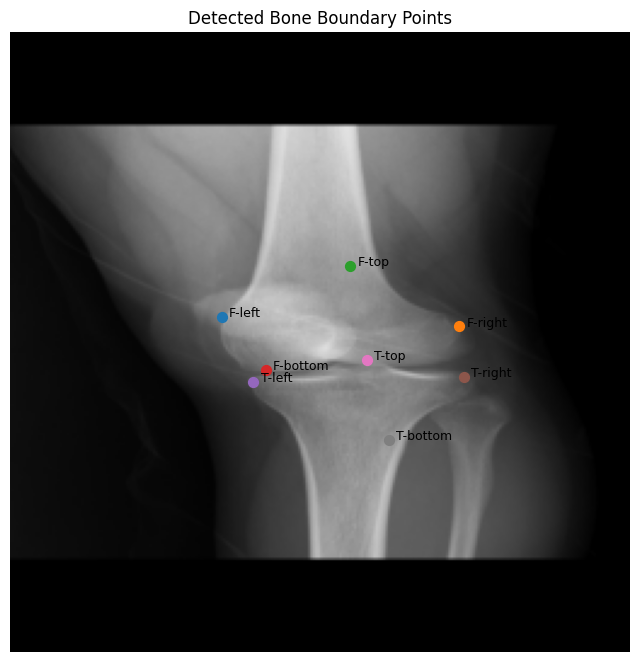

In [109]:
plt.figure(figsize=(8, 10))

plt.imshow(img_resized, cmap="gray")

# Femur
for name, point in femur_points.items():
    x, y = point
    plt.scatter(x, y, s=50)
    plt.text(x + 3, y, f"F-{name}", fontsize=9)

# Tibia
for name, point in tibia_points.items():
    x, y = point
    plt.scatter(x, y, s=50)
    plt.text(x + 3, y, f"T-{name}", fontsize=9)

plt.title("Detected Bone Boundary Points")
plt.axis("off")
plt.show()

In [110]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

femur_contours, _ = cv2.findContours(
    femur_clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

tibia_contours, _ = cv2.findContours(
    tibia_clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

femur_contour = max(femur_contours, key=cv2.contourArea)
tibia_contour = max(tibia_contours, key=cv2.contourArea)

print("Femur contour points:", len(femur_contour))
print("Tibia contour points:", len(tibia_contour))

Femur contour points: 218
Tibia contour points: 184


In [111]:
ys = np.where(femur_clean > 0)[0]

femur_top = ys.min()
femur_bottom = ys.max()

femur_height = femur_bottom - femur_top

distal_start = int(
    femur_bottom - 0.30 * femur_height
)

distal_femur_mask = femur_clean.copy()

distal_femur_mask[:distal_start, :] = 0

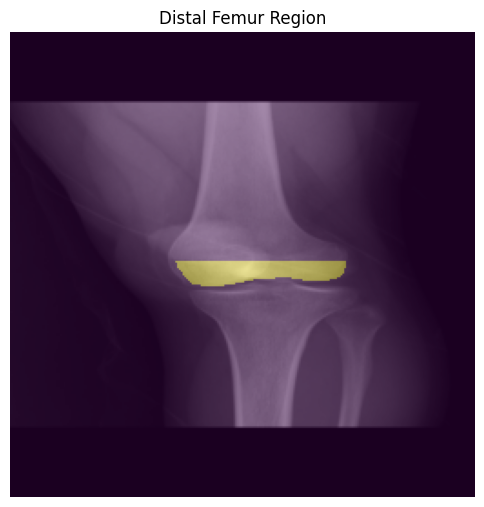

In [112]:
plt.figure(figsize=(6, 8))

plt.imshow(img_resized, cmap="gray")
plt.imshow(
    distal_femur_mask,
    alpha=0.4
)

plt.title("Distal Femur Region")
plt.axis("off")
plt.show()

In [113]:
ys, xs = np.where(distal_femur_mask > 0)

# Find the lowest y-coordinate
max_y = ys.max()

# Look near the bottom of the femur
region = ys >= max_y - 10

bottom_x = xs[region]
bottom_y = ys[region]

print("Bottom boundary points:", len(bottom_x))

Bottom boundary points: 729


In [114]:
x_mid = (bottom_x.min() + bottom_x.max()) / 2

left_points = bottom_x < x_mid
right_points = bottom_x >= x_mid

In [115]:
left_x = bottom_x[left_points]
left_y = bottom_y[left_points]

right_x = bottom_x[right_points]
right_y = bottom_y[right_points]

left_idx = np.argmax(left_y)
right_idx = np.argmax(right_y)

F_left = (
    int(left_x[left_idx]),
    int(left_y[left_idx])
)

F_right = (
    int(right_x[right_idx]),
    int(right_y[right_idx])
)

print("Candidate femur landmarks:")
print("Left:", F_left)
print("Right:", F_right)

Candidate femur landmarks:
Left: (105, 139)
Right: (161, 136)


In [136]:
ys = np.where(tibia_clean > 0)[0]

tibia_top = ys.min()
tibia_bottom = ys.max()

tibia_height = tibia_bottom - tibia_top

proximal_end = int(
    tibia_top + 0.30 * tibia_height
)

proximal_tibia_mask = tibia_clean.copy()

proximal_tibia_mask[proximal_end:, :] = 0

In [117]:
ys, xs = np.where(proximal_tibia_mask > 0)

min_y = ys.min()

region = ys <= min_y + 10

top_x = xs[region]
top_y = ys[region]

x_mid = (top_x.min() + top_x.max()) / 2

left = top_x < x_mid
right = top_x >= x_mid

In [118]:
left_x = top_x[left]
left_y = top_y[left]

right_x = top_x[right]
right_y = top_y[right]

T_left = (
    int(left_x[np.argmin(left_y)]),
    int(left_y[np.argmin(left_y)])
)

T_right = (
    int(right_x[np.argmin(right_y)]),
    int(right_y[np.argmin(right_y)])
)

print("Candidate tibial landmarks:")
print("Left:", T_left)
print("Right:", T_right)

Candidate tibial landmarks:
Left: (142, 138)
Right: (147, 135)


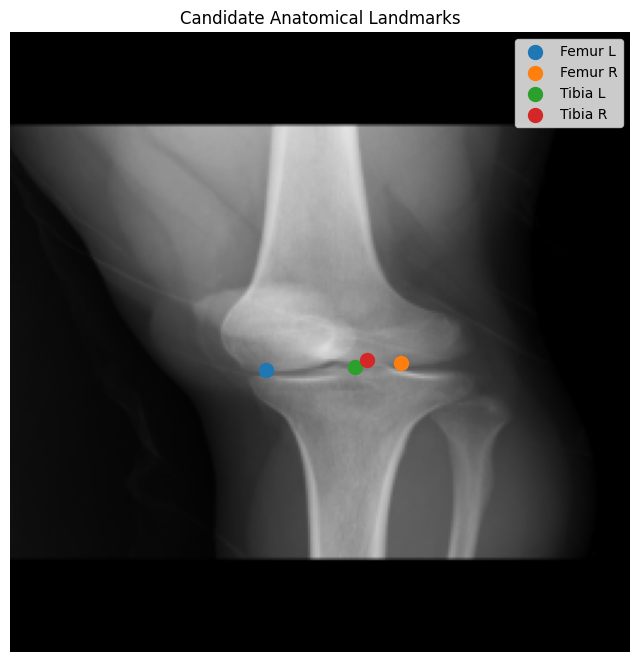

In [119]:
plt.figure(figsize=(8, 10))

plt.imshow(img_resized, cmap="gray")

plt.scatter(
    F_left[0], F_left[1],
    s=100,
    label="Femur L"
)

plt.scatter(
    F_right[0], F_right[1],
    s=100,
    label="Femur R"
)

plt.scatter(
    T_left[0], T_left[1],
    s=100,
    label="Tibia L"
)

plt.scatter(
    T_right[0], T_right[1],
    s=100,
    label="Tibia R"
)

plt.legend()
plt.title("Candidate Anatomical Landmarks")
plt.axis("off")

plt.show()

In [120]:
landmarks = {
    "femur_left": F_left,
    "femur_right": F_right,
    "tibia_left": T_left,
    "tibia_right": T_right
}

for name, point in landmarks.items():
    print(name, ":", point)

femur_left : (105, 139)
femur_right : (161, 136)
tibia_left : (142, 138)
tibia_right : (147, 135)


In [137]:
import numpy as np
import matplotlib.pyplot as plt

def get_maximum_width(mask):
    """
    Finds the maximum horizontal width of a segmented structure.
    Returns width and the row where it occurs.
    """
    best_width = 0
    best_y = None
    best_x1 = None
    best_x2 = None

    for y in range(mask.shape[0]):
        x = np.where(mask[y] > 0)[0]

        if len(x) >= 2:
            width = x[-1] - x[0] + 1

            if width > best_width:
                best_width = width
                best_y = y
                best_x1 = x[0]
                best_x2 = x[-1]

    return best_width, best_y, best_x1, best_x2


# Calculate ML dimensions
femur_ml_px, femur_y, femur_x1, femur_x2 = get_maximum_width(
    femur_clean
)

tibia_ml_px, tibia_y, tibia_x1, tibia_x2 = get_maximum_width(
    tibia_clean
)

print("Femur ML:", femur_ml_px, "pixels")
print("Tibia ML:", tibia_ml_px, "pixels")

Femur ML: 99 pixels
Tibia ML: 88 pixels


In [138]:
pixel_spacing = 0.25  # replace with actual calibrated spacing

femur_ml_mm = femur_ml_px * pixel_spacing
tibia_ml_mm = tibia_ml_px * pixel_spacing

print(f"Femoral ML: {femur_ml_mm:.2f} mm")
print(f"Tibial ML:  {tibia_ml_mm:.2f} mm")

Femoral ML: 24.75 mm
Tibial ML:  22.00 mm


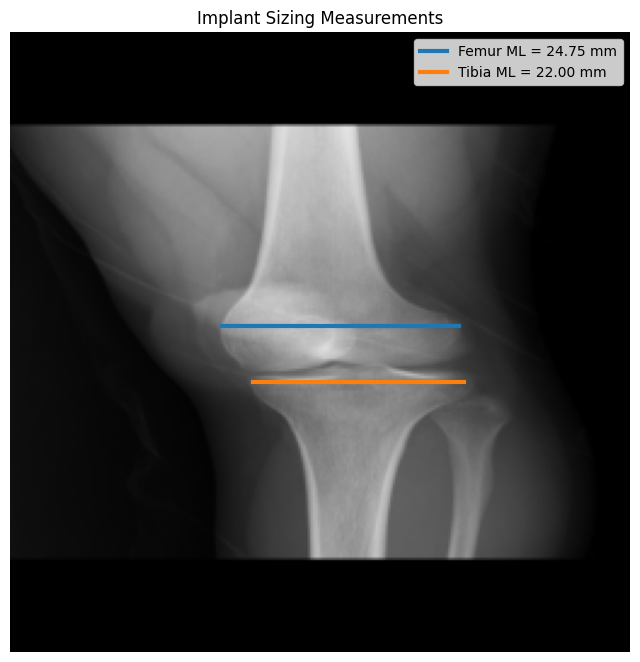

In [139]:
plt.figure(figsize=(8, 10))

plt.imshow(img_resized, cmap="gray")

# Femur ML
if femur_y is not None:
    plt.plot(
        [femur_x1, femur_x2],
        [femur_y, femur_y],
        linewidth=3,
        label=f"Femur ML = {femur_ml_mm:.2f} mm"
    )

# Tibia ML
if tibia_y is not None:
    plt.plot(
        [tibia_x1, tibia_x2],
        [tibia_y, tibia_y],
        linewidth=3,
        label=f"Tibia ML = {tibia_ml_mm:.2f} mm"
    )

plt.title("Implant Sizing Measurements")
plt.legend()
plt.axis("off")
plt.show()